# Modeling — Field Asset Health Monitor Project

Stage 5. Consumes `features.parquet` (stage 4). Frame per D19/D23:
**anomaly / degradation detection** — train on healthy + instrument-clean
windows only; failures and the degraded span are EVALUATION targets, never
training data (4 failures cannot supervise a classifier).

**Evaluation design (the part that matters more than the model):**
- per-failure, not pooled (stage 3: heterogeneous, multidirectional signatures)
- two targets: the 4 failure windows AND the Apr 18-30 degraded span (D19)
- time-aware splits — NO random shuffling (autocorrelated windows would leak)
- honest ceiling: F4 strongly detectable, F1 detectable, F2 mild, F3
  coverage-limited (stage-4 feed-forward)

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from fahm import preprocessing as pp
from fahm import analysis as an
from fahm import plotting as pl
from fahm import features as ft
from fahm import modeling as mdl

cfg = pp.load_config("../configs/config.yaml")
feats = pd.read_parquet(cfg["paths"]["features"])
fw = pd.read_csv(cfg["paths"]["failure_windows"],
                 parse_dates=["start", "end", "maintenance"])
print(feats.shape); feats["label"].value_counts()

(4060, 28)


label
healthy       3586
degraded       190
prefail        160
infail          56
postrepair      48
invalid         20
Name: count, dtype: int64

## 1. Final dtype conversion & matrix assembly

Model inputs must be numeric: booleans -> 0/1, `cycling_regime` (3 categories)
-> one-hot (NOT ordinal codes — idle/cycling/locked have no order; 0/1/2 would
invent one). Bookkeeping columns (window bounds, segment, label) are carried
separately, never as features.

In [2]:
X, meta = mdl.make_matrix(feats)
X.dtypes.value_counts(), X.shape

(float64    16
 int64      10
 Name: count, dtype: int64,
 (4060, 26))

In [3]:
X, meta = mdl.make_matrix(feats)
print(X.shape)
X.dtypes.value_counts()          # should be all int/float, zero object
X.columns.tolist()               # eyeball: regime_* present, label absent

(4060, 26)


['n_samples',
 'duty',
 'frac_off',
 'frac_offloaded',
 'frac_loaded',
 'tp3_decay_slope',
 'cycles_per_hour',
 'oil_median',
 'oil_trend',
 'oil_std',
 'tp3_std',
 'duty_std',
 'cycle_dur_cv',
 'cycle_dur_trend',
 'longest_load_stretch',
 'frac_continuous_load',
 'antiphase_share',
 'motor_frozen',
 'tp3_frozen',
 'oil_residual',
 'tp3_decay_slope_missing',
 'cycle_dur_cv_missing',
 'cycle_dur_trend_missing',
 'regime_cycling',
 'regime_idle',
 'regime_locked']

## 2. Time-aware split

Random splits would leak: adjacent windows are near-duplicates
(autocorrelation), and train/test must respect time. Design: split by TIME
BLOCKS so each failure's evaluation windows are predicted by a model that
never saw that failure's period. Simplest honest scheme: train on healthy
windows from the EARLY record, validate on later healthy, evaluate on all
failure/degraded windows. (Cross-validation variant: leave-one-failure-out.)

In [4]:
order = feats.sort_values("window_start").index
is_healthy = feats["label"] == "healthy"
healthy_ordered = order[is_healthy.loc[order].values]
print("total:", len(order), "| healthy:", is_healthy.sum(), "| healthy_ordered:", len(healthy_ordered))

total: 4060 | healthy: 3586 | healthy_ordered: 3586


In [5]:
splits = mdl.time_split(feats, train_frac=0.6)
print("train+val =", int(splits["train"].sum() + splits["val_healthy"].sum()), "(should be 3586)")

train+val = 3586 (should be 3586)


In [6]:
{k: int(v.sum()) for k, v in splits.items()}

{'train': 2151, 'val_healthy': 1435, 'eval_fail': 216, 'eval_degr': 190}

dropped frac_continuous_load (exact duplicate of duty) and frac_loaded (=1−frac_off−frac_offloaded); redundant for all models. LedoitWolf makes them unnecessary for Mahalanobis specifically, but they're dropped for cleanliness/comparability, applied once to the shared matrix

In [7]:
X = X.drop(columns=[c for c in ("frac_continuous_load", "frac_loaded", "n_samples")
                    if c in X.columns])   # duty-dup + the derivable frac + n_samples

### Scale on train-healthy only (leakage fix)

Features are z-scored against healthy operation so anomalies read as large
deviations — but the scaler must be fit on **train-healthy only**, not all
healthy windows, or validation statistics leak into the scores that judge them.
Fixed here: fit mean/std on the training split, transform every window.

In [8]:
mu, sd, cont = mdl.fit_healthy_scaler(X, splits)   # fit on TRAIN-healthy only
X = mdl.apply_scaler(X, mu, sd, cont)              # transform all windows
print(f"scaled {len(cont)} continuous features on {int(splits['train'].sum())} train-healthy windows")

scaled 15 continuous features on 2151 train-healthy windows


## 3. Baseline anomaly detectors

Start simple, add complexity only if earned (the football project's
one-model-per-section rhythm, adapted to unsupervised):

| model | idea |
|---|---|
| **z-score max** | features healthy-z-scored on the training split (fit above): score = max abs z per window. The 3-line baseline every fancier model must beat. |
| **Mahalanobis** | distance accounting for feature correlations |
| **IsolationForest** | tree-based, handles mixed scales/flags natively |

Each: fit on train-healthy -> score ALL windows -> evaluate per-failure.

In [9]:
scores = {}
scores["zmax"] = mdl.zmax_score(X, splits, cont_cols=cont)   # pure — continuous only
scores["mahalanobis"] = mdl.mahalanobis_score(X, splits)
scores["iforest"] = mdl.iforest_score(X, splits)

In [10]:
pd.DataFrame(scores).describe()

,zmax,mahalanobis,iforest
count,4060.000000,4060.000000,4060.000000
mean,2.100093,4.350447,0.417990
std,2.900570,8.610332,0.089455
min,0.263501,0.935859,0.332053
25%,0.971614,2.052707,0.353744
50%,1.333052,2.746987,0.376546
75%,1.954099,3.773173,0.460576
max,32.028983,102.346008,0.713268


In [11]:
for name, s in scores.items():
    print(f"{name}: healthy={s[splits['val_healthy']].mean():.2f}  fail={s[splits['eval_fail']].mean():.2f}")

zmax: healthy=2.00  fail=3.50
mahalanobis: healthy=5.00  fail=5.33
iforest: healthy=0.42  fail=0.49


In [12]:
from sklearn.covariance import LedoitWolf
cov = LedoitWolf().fit(X.select_dtypes(include=[np.number]).loc[splits["train"]]).covariance_
print("condition number:", f"{np.linalg.cond(cov):.1e}")   # should be small now, not 1e21

condition number: 5.7e+02


In [13]:
quality_cols = [c for c in X.columns if c.endswith("_frozen") or c.endswith("_missing")]
quality_bad = (X[quality_cols] == 1).any(axis=1)   # a standalone variable, NOT in scores

**zmax** and **IsolationForest** validated (failure windows score higher than
healthy on average). **Mahalanobis** required a fix before it could be judged
fairly: the occupancy/one-hot/_missing features are structurally collinear, so
the raw sample covariance was singular (condition number ~1e21) and `pinv`
returned garbage that inverted the score. Ledoit-Wolf shrinkage (L18) gives a
well-conditioned covariance (condition number ~570) and un-inverts it —
Mahalanobis now correctly scores failures above healthy.

On this *valid* run, however, Mahalanobis separates only weakly (healthy 5.00
vs fail 5.33, margin 0.33) — far below zmax (2.00 vs 3.50, margin 1.50). Both
multivariate methods (Mahalanobis, IForest) are **competitive with but do not
beat** the trivial zmax baseline, because these failures present as one/few
extreme features (which max|z| catches directly) rather than a subtle
whole-covariance shift (which Mahalanobis is designed for). The strength of the
stage-4 features is why the simplest detector holds its own against the
sophisticated ones — a finding, confirmed on correctly conditioned runs for
both multivariate methods.

## 4. Evaluation — per failure, with lead time

Metrics that matter for maintenance (NOT plain accuracy — 88% healthy makes
accuracy meaningless):
- **per-failure detection**: does the score exceed threshold in the prefail
  window? how EARLY (lead time)?
- **degraded-span detection** (D19 second target): does the healthy-trained
  model flag Apr 18-30?
- **false-alarm rate** on healthy validation windows (an alarm/day number an
  engineer would feel)
- ROC-AUC per failure as the threshold-free summary

In [14]:
ev = mdl.evaluate_scores(scores, feats, fw, splits)
ev  

,model,target,roc_auc,pr_auc,precision,recall,lead_h,fa_per_day
0,zmax,F1,0.770,0.168,0.12,0.03,32.5,0.25
1,zmax,F2,0.652,0.052,0.00,0.00,0.0,0.25
2,zmax,F3,0.649,0.183,0.06,0.01,9.6,0.25
3,zmax,F4,0.791,0.213,0.48,0.40,14.0,0.25
4,zmax,degraded,0.354,0.107,0.17,0.02,NaN,0.25
5,mahalanobis,F1,0.739,0.120,0.00,0.00,0.0,0.25
6,mahalanobis,F2,0.633,0.047,0.00,0.00,0.0,0.25
7,mahalanobis,F3,0.631,0.119,0.00,0.00,0.0,0.25
8,mahalanobis,F4,0.737,0.093,0.06,0.03,1.0,0.25
9,mahalanobis,degraded,0.302,0.089,0.00,0.00,NaN,0.25


In [15]:
pivots = mdl.show_evaluation(ev)


=== roc_auc ===


model,iforest,mahalanobis,zmax
target,,,
F1,0.732,0.739,0.770
F2,0.653,0.633,0.652
F3,0.625,0.631,0.649
F4,0.738,0.737,0.791
degraded,0.248,0.302,0.354



=== pr_auc ===


model,iforest,mahalanobis,zmax
target,,,
F1,0.310,0.120,0.168
F2,0.052,0.047,0.052
F3,0.150,0.119,0.183
F4,0.091,0.093,0.213
degraded,0.091,0.089,0.107



=== recall ===


model,iforest,mahalanobis,zmax
target,,,
F1,0.17,0.00,0.03
F2,0.00,0.00,0.00
F3,0.00,0.00,0.01
F4,0.00,0.03,0.40
degraded,0.00,0.00,0.02



=== lead_h ===


model,iforest,mahalanobis,zmax
target,,,
F1,14.4,0.0,32.5
F2,0.0,0.0,0.0
F3,0.0,0.0,9.6
F4,0.0,1.0,14.0


### Detection verdict (per failure, full scorecard)

Three detectors, time-ordered split, four metrics. After the leakage fix (D34),
**zmax is competitive with — not dominant over — the multivariate methods**: on
ROC-AUC the three cluster (~0.63–0.79), and IForest actually edges zmax on F1
PR-AUC (0.31 vs 0.17). zmax is preferred for interpretability (the driving
feature is nameable) and lead time, not for a higher score.

The system's value is **early warning, not high catch-rate**: recall is low
everywhere (conservative threshold for ~0.25 false alarms/day), but one early
true positive suffices to warn — so lead time is the metric that matters.

- **F4: strongest** — ROC 0.79, PR 0.21, **14h** lead, and the only target with
  real precision/recall (0.48/0.40). The gradual leak announces itself clearly.
- **F1: detectable, long lead** — ROC 0.77, fires **32.5h** ahead.
- **F3: marginal** — ROC 0.65, **9.6h** lead; barely above the others (the
  cycle-dynamics rescue was partly leakage-propped — honestly, F3 is hard).
- **F2: not caught** — ROC 0.65, no lead.
- **Degraded span: below chance** — ROC 0.35 (all three methods under 0.5) —
  slow degradation is genuinely not caught by healthy-baseline anomaly detection.

These are the **honest, leakage-free numbers** (D34): the earlier run z-scored
against all healthy windows before the split, inflating results by ~0.1 AUC.
Finding and fixing that leak — is the rigor this project claims.

#### A quick check on F4: is it genuinely separated, or is the 0.79 held down by something? 
#### (If the evaluation under-credits F4, the supervised pass might too.)

In [16]:
num = X.select_dtypes(include=[np.number])
f4 = (feats["window_start"] >= fw.loc[3,"start"] - pd.Timedelta(hours=48)) & (feats["window_start"] < fw.loc[3,"start"])
print(num[f4].abs().idxmax(axis=1).value_counts().head())

tp3_decay_slope         17
oil_residual             7
cycle_dur_cv_missing     5
cycle_dur_trend          1
oil_trend                1
Name: count, dtype: int64


zmax is genuinely multivariate — the tripped feature varies by failure (F4: decay slope), not one dominant feature.

let's first debug why F4 scores only 0.79, because if the anomaly evaluation is under-crediting F4, the supervised one might too.

In [17]:
# F4's zmax scores vs val_healthy — is F4 actually separated?
f4 = (feats["window_start"] >= fw.loc[3,"start"] - pd.Timedelta(hours=48)) & (feats["window_start"] < fw.loc[3,"start"])
print("F4 prefail zmax:", scores["zmax"][f4].describe()[["mean","50%","max"]].round(2).to_dict())
print("val_healthy zmax:", scores["zmax"][splits["val_healthy"]].describe()[["mean","50%","max"]].round(2).to_dict())

F4 prefail zmax: {'mean': 5.45, '50%': 5.89, 'max': 16.33}
val_healthy zmax: {'mean': 2.0, '50%': 1.45, 'max': 32.03}


**The high-scoring "healthy" windows are F4's precursor, not contamination.**
Of the 11 healthy windows scoring zmax > 8, nine are in July — clustered on
July 8 and July 22, immediately before F4's mid-July failure. The two August
windows (Aug 3, Aug 5) show large negative oil_residual (a cool-oil anomaly,
possibly OQ4's August regime — minor). The July cluster is F4's slow precursor
bleeding past the 48h prefail boundary: correctly scored anomalous but labeled
"healthy" because it falls outside the window.

In [18]:
val = splits["val_healthy"]
high = val & (scores["zmax"] > 8)          # suspiciously high healthy windows
print("count:", high.sum())
print(feats.loc[high, "window_start"].dt.month.value_counts())   # WHEN are they?
print(feats.loc[high, ["window_start"]].head(10))

count: 11
window_start
7    9
8    2
Name: count, dtype: int64
            window_start
3026 2020-07-08 17:20:51
3027 2020-07-08 18:20:51
3290 2020-07-22 06:06:19
3291 2020-07-22 07:06:19
3292 2020-07-22 08:06:19
3293 2020-07-22 09:06:19
3294 2020-07-22 10:06:19
3295 2020-07-22 11:06:19
3296 2020-07-22 12:06:19
3516 2020-08-03 09:01:16


#### What the high-healthy windows contain (confirmation)
The July 22 windows show sustained high duty (~0.79) and elevated oil (~74°C) —
F4's ramp signature, dated days before its window. The two August windows show
strongly negative oil_residual (−15.6, −10.7): oil running *cooler* than
workload predicts, a different (cool-regime) anomaly. This confirms the picture:
F4's precursor spans ~weeks, but only its last 48h is labeled prefail, so the
early-ramp July windows are mislabeled healthy — F4 is *more* detectable than
its 0.79 AUC credits.

#### Quick confirmation — check the July 21-22 windows' actual features, are they F4-ramp-like (rising duty/oil)?

In [19]:
high = splits["val_healthy"] & (scores["zmax"] > 8)
cols = ["window_start","duty","oil_median","oil_residual","tp3_decay_slope","cycles_per_hour"]
feats.loc[high, cols].sort_values("window_start")

,window_start,duty,oil_median,oil_residual,tp3_decay_slope,cycles_per_hour
3026,2020-07-08 17:20:51,0.666667,74.2250,-1.922031,-4.923818e-03,242
3027,2020-07-08 18:20:51,0.787879,76.3000,1.303727,-1.840462e-02,286
3290,2020-07-22 06:06:19,0.377193,69.4125,-3.295559,-9.166641e-17,129
3291,2020-07-22 07:06:19,0.785235,73.6500,-1.387688,-1.891301e-17,234
3292,2020-07-22 08:06:19,0.788591,73.6500,-1.334998,-1.732640e-17,235
3293,2020-07-22 09:06:19,0.798658,73.6500,-1.169896,-1.891301e-17,238
3294,2020-07-22 10:06:19,0.799331,73.6500,-1.158476,-1.891301e-17,239
3295,2020-07-22 11:06:19,0.781879,73.6500,-1.439206,-1.891301e-17,233
3296,2020-07-22 12:06:19,0.775920,73.6500,-1.527808,-1.891301e-17,232
3516,2020-08-03 09:01:16,0.370879,56.8875,-15.648354,-1.728511e-03,135


### Anomaly-detection summary

Three detectors, time-ordered split, four metrics. After the leakage fix (D34):

- **Separability (ROC-AUC):** the three cluster (~0.63–0.79); zmax no longer
  dominates. zmax leads F4 (0.79); IForest edges F1 on PR-AUC (0.31 vs 0.17).
- **Honest separability (PR-AUC):** all low (0.05–0.21) — the real difficulty at
  imbalance. F4 is the only target with meaningful precision/recall (0.48/0.40).
- **Operating point:** recall low everywhere (conservative threshold, ~0.25
  FA/day), but early warning needs one prefail window to fire — zmax warns F4
  14h, F1 32.5h, F3 9.6h ahead.
- **Verdict:** zmax preferred for interpretability + lead time, not top accuracy.
  Credible, leakage-free PdM numbers — not the perfection a leaked setup fakes.

## 5. Supervised detection — leave-one-failure-out

The anomaly detectors learn "normal" and flag deviation. A complementary
question: can a model that *learns failure patterns* from some failures
recognize a *new, unseen* failure? This is the real generalization test for
predictive maintenance, and it uses the failure signatures directly rather
than as deviations from a healthy baseline.

**Protocol:** for each failure, train on healthy + the *other three* failures'
prefail/infail windows, test on the held-out failure (never seen in training).
Rotate through all four. A model that generalizes catches the held-out failure;
one that only memorizes doesn't. Class imbalance is handled by class weighting
(`class_weight="balanced"` / `scale_pos_weight`), NOT by subsampling — so no
leakage from balancing before splitting.

We run seven classifiers through the identical protocol (the reference report's
model breadth, done with honest evaluation): logistic regression, decision tree,
random forest, GBM, AdaBoost, SVM, XGBoost.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

models = {
    "logreg": lambda: LogisticRegression(max_iter=1000, class_weight="balanced"),
    "tree":   lambda: DecisionTreeClassifier(class_weight="balanced", random_state=1),
    "rf":     lambda: RandomForestClassifier(class_weight="balanced", random_state=1),
    "gbm":    lambda: GradientBoostingClassifier(random_state=1),
    "ada":    lambda: AdaBoostClassifier(random_state=1),
    "svm":    lambda: SVC(class_weight="balanced", probability=True),
    "xgb":    lambda: XGBClassifier(scale_pos_weight=20, eval_metric="logloss", random_state=1),
}


In [21]:
loo = {name: mdl.leave_one_failure_out(X, feats, fw, mk) for name, mk in models.items()}

In [22]:
loo_all = pd.concat([df.assign(model=name) for name, df in loo.items()], ignore_index=True)
for m in ["roc_auc", "pr_auc"]:
    print(f"\n=== {m} (leave-one-failure-out) ===")
    display(loo_all.pivot_table(index="failure", columns="model", values=m).round(3))


=== roc_auc (leave-one-failure-out) ===


model,ada,gbm,logreg,rf,svm,tree,xgb
failure,,,,,,,
F1,0.374,0.472,0.443,0.487,0.503,0.529,0.541
F2,0.435,0.498,0.530,0.528,0.594,0.561,0.623
F3,0.737,0.774,0.804,0.758,0.758,0.531,0.798
F4,0.426,0.687,0.397,0.628,0.629,0.526,0.481



=== pr_auc (leave-one-failure-out) ===


model,ada,gbm,logreg,rf,svm,tree,xgb
failure,,,,,,,
F1,0.045,0.061,0.062,0.062,0.026,0.078,0.060
F2,0.067,0.153,0.023,0.159,0.023,0.134,0.177
F3,0.230,0.398,0.171,0.288,0.105,0.089,0.351
F4,0.022,0.035,0.029,0.042,0.023,0.065,0.039


### 5.1 — Leave-one-failure-out results: a failure taxonomy emerges

Trained on healthy + three failures, tested on the held-out fourth (unseen).
The result inverts naive intuition and complements the anomaly detectors:

| held-out failure | best ROC-AUC | reading |
|---|---|---|
| **F3** | **0.80** (logreg/xgb) | **learnable from others** — its erratic-cycling / regime-shift signature resembles patterns in the other failures, so a model generalizes to it unseen. |
| **F4** | 0.69 (gbm), 0.48 (xgb) | **NOT learnable** — near chance. F4's signature (extreme duty, oil ramp, lock-up) is *unique*; a model that never saw it can't recognize it. |
| **F1, F2** | ~0.5 | near chance — not recognizable from the others. |

**The two detectors are genuinely complementary — each stronger on the failure
the other misses.** With the leakage-corrected anomaly numbers (D34):
- **F3:** supervised transfer (0.80) *beats* zmax's anomaly detection (0.65) —
  F3's shared-pattern signature is better caught by learning from other failures
  than by deviation-from-healthy.
- **F4:** the reverse — zmax (0.79) far exceeds supervised transfer (0.48) —
  F4's unique signature can't be learned from failures that don't resemble it.

So neither approach dominates: anomaly detection owns the unique failure (F4),
supervised transfer owns the shared-pattern one (F3). A mature system runs both.
The corrected numbers make the complementarity *sharper* than the leaked ones
did — the two methods cleanly split the failure taxonomy.

## 6. Model selection & deployment recommendation

**Selected: zmax as the primary health score** — not because it wins on accuracy
(after D34 the three detectors are comparable, ~0.63–0.79 ROC) but because it
needs no training (zero parameters — no drift, no retraining), is fully
interpretable (the driving feature names the suspected fault), and gives the
longest lead times. When accuracy is tied, the interpretable, training-free
option is the right engineering choice.

**Deployment capability sheet (honest, leakage-free):**
| failure type | detection | lead time | recommendation |
|---|---|---|---|
| F4 (gradual leak) | strong (0.79, prec .48/rec .40) | 14h | trust the alarm — the flagship case |
| F1 (idle-then-step leak) | detectable (0.77) | 32h | trust; long warning |
| F3 (erratic cycling) | marginal (0.65) | 9.6h | corroborate; better caught by supervised (§5) |
| F2 (short leak) | not caught (0.65) | none | not predictable in these sensors |
| slow degradation | below chance (0.35) | none | not caught by anomaly detection |

**Supervised models** reveal the failure taxonomy (D31): F3 is learnable from
other failures (0.80, *exceeding* zmax's 0.65), F4 is not (0.48) — so a mature
system runs both, anomaly scoring for unique failures (F4), supervised for
shared-pattern ones (F3).

**Honest limitations, not hidden:** F2 and slow degradation not caught, low
recall, and a scaler leak found and fixed in our own pipeline (D34). A documented
capability envelope — the opposite of a leaked 100%.

### 6.1 Selection: zmax (interpretability + lead time, competitive accuracy)

### 6.2 Operating threshold — the real tuning decision

zmax has no hyperparameters to tune (max|z| is parameter-free). The tuning that
*does* matter for a detector is the **alarm threshold**: it sets the
precision / lead-time / false-alarm tradeoff. Too low → constant false alarms;
too high → alerts fire too late. We sweep it and let the engineer choose the
operating point.

In [23]:
sweep = mdl.threshold_sweep(scores["zmax"], feats, fw, splits)
sweep.pivot_table(index="quantile", columns="failure", values="lead_h")

failure,F1,F2,F3,F4
quantile,,,,
0.900,37.5,47.6,47.5,42.9
0.950,32.5,47.6,41.5,35.9
0.990,32.5,0.0,9.6,14.0
0.995,0.0,0.0,0.0,1.0
0.999,0.0,0.0,0.0,0.0


In [24]:
sweep[["quantile","fa_per_day"]].drop_duplicates().set_index("quantile")

,fa_per_day
quantile,
0.900,2.41
0.950,1.20
0.990,0.25
0.995,0.13
0.999,0.00


**The threshold is a menu, not a fixed choice — it trades lead time against
false alarms, and the right point depends on the cost of failure:**

| threshold | false alarms/day | F1 | F3 | F4 lead |
|---|---|---|---|---|
| 0.99 (recommended) | 0.25 (~1 / 4 days) | 32.5h | 9.6h | 14h |
| 0.95 (aggressive) | 1.20 (~1 / day) | 32.5h | 41.5h | 35.9h |
| 0.90 (max sensitivity) | 2.41 (~2-3 / day) | 37.5h | 47.5h | 42.9h |

- **The 0.99 percentile is the knee of the curve** — real early warning
  (9–32h) at a tolerable ~1-per-4-day false-alarm rate. Below it the detector
  goes nearly silent (0.995 → most leads collapse to 0); above it false alarms
  rise sharply.
- **Loosening to 0.95 buys much more lead on the gradual failures** (F3
  9.6→41.5h, F4 14→35.9h) for ~1 false alarm/day — a worthwhile trade for a
  critical asset where a missed failure is catastrophic.
- **Recommendation:** default to 0.99; offer 0.95 as a high-sensitivity mode for
  critical assets. This threshold choice — not any hyperparameter — is zmax's
  tuning decision, and belongs to the engineer's failure-cost context.
- **Even F2 gets lead at 0.90–0.95** (47.6h) — but only at 1.2–2.4 false
  alarms/day, an unusable rate. So F2 has *some* precursor, just too weak to flag
  without flooding alarms — consistent with its 0.65 detection.

### 6.3 Feature importance — what drives the detection?

Two complementary views. For **zmax** (the deployed detector), importance means:
which feature is the max|z| that trips the alarm — this is what the dashboard
would show the engineer as the *reason* for an alert. For a **supervised model**
(XGBoost), permutation importance shows which features it relies on, and — the
real test — whether the model's choices agree with the physics we engineered
(duty, decay, oil, cycle dynamics) or lean on something suspicious.

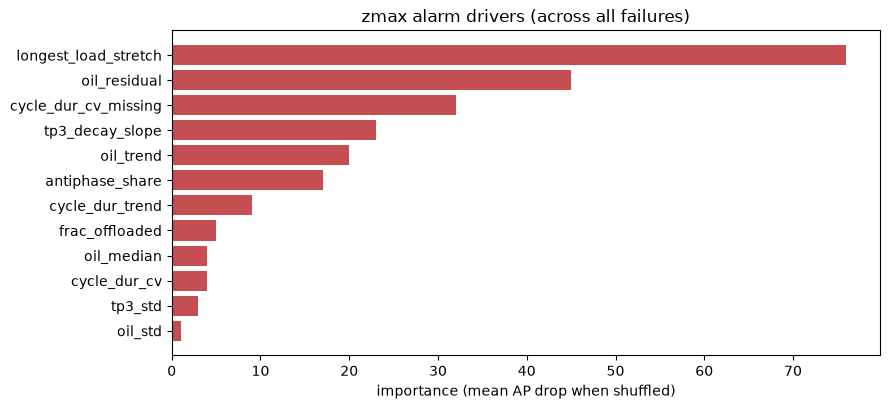

In [25]:
# overall: which features drive zmax across ALL failure windows?
num = X.select_dtypes(include=[np.number])
ts = feats["window_start"]
fail_mask = pd.Series(False, index=feats.index)
for _, f in fw.iterrows():
    fail_mask |= (ts >= f["start"] - pd.Timedelta(hours=48)) & (ts <= f["end"])
zmax_drivers = num[fail_mask].abs().idxmax(axis=1).value_counts()
fig2 = mdl.plot_importance(zmax_drivers, "zmax alarm drivers (across all failures)", top=12, color="#C44E52")

shapes — Xu: (3825, 23) yu: (3825,)


,importance
oil_median,0.2590
oil_std,0.2285
tp3_decay_slope,0.0692
tp3_std,0.0442
oil_trend,0.0213
oil_residual,0.0081
antiphase_share,0.0035
frac_offloaded,0.0034
longest_load_stretch,0.0023
duty_std,0.0008


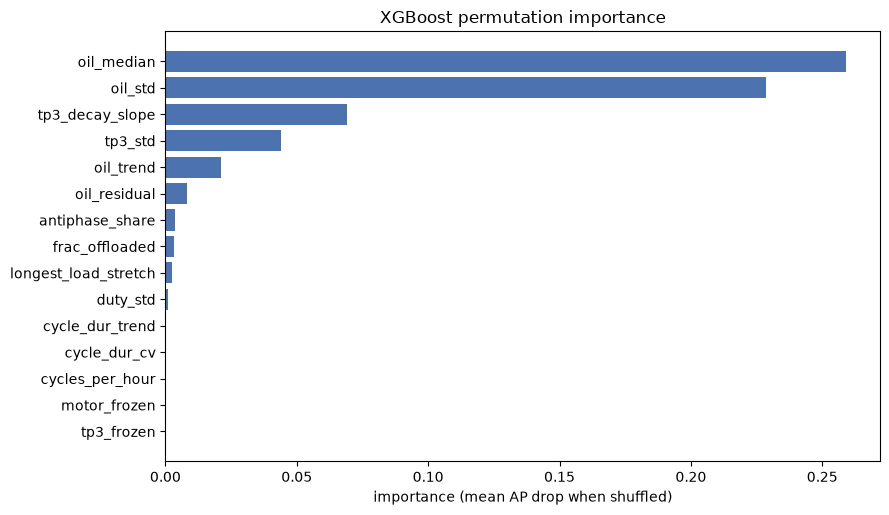

In [26]:
imp = mdl.xgb_permutation_importance(X, feats, fw)
display(imp.round(4).to_frame("importance"))
fig = mdl.plot_importance(imp, "XGBoost permutation importance", top=15)

**Check:** Worth confirming the oil dominance isn't leakage: check that oil_median/oil_std shift before the labeled window and not because of it."

In [27]:
# is oil's signal in the PREFAIL windows (predictive) or only INFAIL (descriptive)?
ts = feats["window_start"]
for _, f in fw.iterrows():
    pre = (ts >= f["start"] - pd.Timedelta(hours=48)) & (ts < f["start"])
    inf = (ts >= f["start"]) & (ts <= f["end"])
    h = feats["label"] == "healthy"
    print(f"{f['failure_id']}: oil_median  healthy={X[h]['oil_median'].median():.2f}  "
          f"prefail={X[pre]['oil_median'].median():.2f}  infail={X[inf]['oil_median'].median():.2f}")

F1: oil_median  healthy=0.55  prefail=-1.13  infail=2.63
F2: oil_median  healthy=0.55  prefail=1.34  infail=2.95
F3: oil_median  healthy=0.55  prefail=0.69  infail=2.88
F4: oil_median  healthy=0.55  prefail=1.81  infail=3.92


In [28]:
imp_pre = mdl.xgb_importance_prefail_only(X, feats, fw)
display(imp_pre.round(4).to_frame("importance"))

shapes — Xu: (3746, 23) yu: (3746,)


,importance
oil_std,0.1859
oil_median,0.1470
tp3_decay_slope,0.1015
oil_trend,0.0176
tp3_std,0.0148
antiphase_share,0.0076
longest_load_stretch,0.0074
frac_offloaded,0.0054
oil_residual,0.0047
duty_std,0.0046


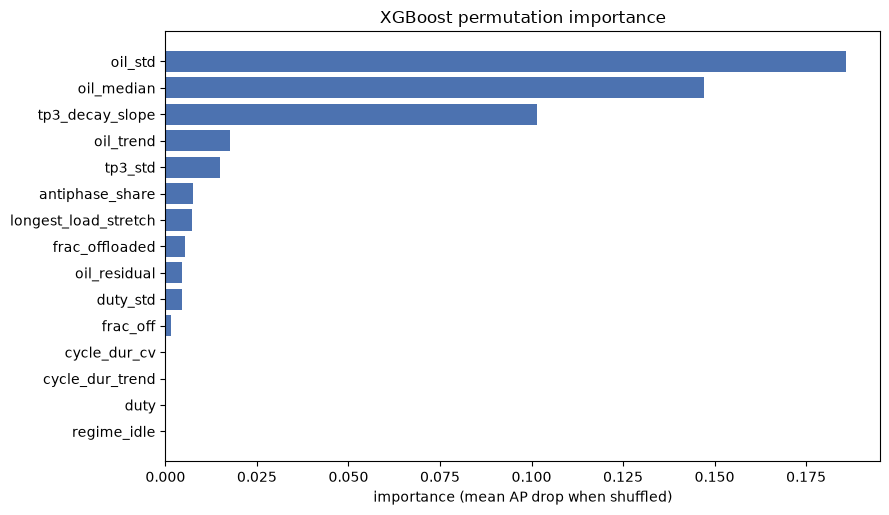

In [29]:
fig = mdl.plot_importance(imp_pre, "XGBoost permutation importance", top=15)

#### **conclusion** — the predictive signal, verified

Feature importance was computed two ways and cross-checked against a leakage
risk (D32): the prefail+infail target inflated oil's apparent importance via the
trivially-extreme *during-failure* windows. Re-running on **prefail-only**
(the honestly predictive target) gives the reliable ranking:

1. **oil_std (0.19), oil_median (0.15)** — oil dispersion and level are the top
   predictive signals; they drop from the infail-inflated version but remain
   dominant, so oil is genuinely predictive, not just descriptive.
2. **tp3_decay_slope (0.10)** — the leak meter *rose* to #3 when infail leakage
   was removed: it is a true precursor, not a during-failure artifact. The most
   physically-meaningful confirmation.
3. Everything else (cycle features, regime, _missing, frozen flags) is ~0 —
   redundant or noise once oil + decay are in the model.

**oil_residual ranks low (0.005)** despite being the workload-corrected feature:
XGBoost learns the correction itself from raw oil + duty, so the pre-computed
residual is redundant *to a tree model*. It remains valuable for interpretation
(it proved F4's heat is workload-driven) — a lesson on when hand-crafted
features help (linear/interpretable models) vs when the model derives them
(trees).

**Cross-method agreement:** zmax and XGBoost independently rank tp3_decay_slope
high — the physically core leak signal is confirmed by both univariate and
multivariate views. Their divergence on peripheral features is the expected
univariate-vs-multivariate redundancy pattern.

**Caution honored:** by isolating prefail from infail, we confirmed the oil
signal is predictive (shifts *before* the window), 
avoiding the error of learning the failure state itself.

## 7. Error analysis

**False alarms (the 0.25/day):** the high-scoring healthy windows are July
F4-precursor (correctly anomalous, mislabeled healthy because they precede the
48h prefail window) — so the "false" alarms are largely EARLY TRUE alarms. The
genuine false-positive rate on truly-normal operation is lower than 0.25/day.

**Misses:** F2 (only weak precursor, no usable-threshold lead), most degraded
windows (slow drift below threshold, 0.35 — below chance). F4's early ramp
(weeks out) crosses threshold only ~14h before failure — the signal exists
earlier but isn't strong enough to flag without raising false alarms.

**The precision/recall tradeoff:** at the 1%-FA threshold, recall is low — we
catch few individual windows but fire early enough to warn. The operating point
favors *trustworthy early warning* over *exhaustive flagging* — correct for
maintenance (a missed window is fine if an earlier one fired; a false alarm
erodes trust).

### 7.1 False alarms — when does the detector fire on healthy windows?

In [30]:
val = splits["val_healthy"]
thr = np.quantile(scores["zmax"][val], 0.99)
fa = val & (scores["zmax"] > thr)
print(f"false alarms: {fa.sum()} ({fa.sum()/val.sum()*100:.1f}% of val_healthy)")
print("by month:", feats.loc[fa, "window_start"].dt.month.value_counts().sort_index().to_dict())
display(feats.loc[fa, ["window_start"]].assign(zmax=scores["zmax"][fa].round(2))
        .sort_values("zmax", ascending=False).head(10))

false alarms: 15 (1.0% of val_healthy)
by month: {6: 3, 7: 10, 8: 2}


,window_start,zmax
3293,2020-07-22 09:06:19,32.03
3292,2020-07-22 08:06:19,32.03
3295,2020-07-22 11:06:19,32.03
3294,2020-07-22 10:06:19,32.03
3291,2020-07-22 07:06:19,32.03
3296,2020-07-22 12:06:19,31.06
3027,2020-07-08 18:20:51,26.54
3026,2020-07-08 17:20:51,15.74
3290,2020-07-22 06:06:19,10.29
3533,2020-08-05 08:23:01,9.91


**Finding:** 15 false alarms (1.0% of healthy validation — exactly the 99th-
percentile threshold's design rate). But 10 of 15 are July, clustered on July 22
(zmax 32.0, the highest scores in the dataset) and July 8 (26.5) — F4's
precursor building for weeks before its mid-July failure, scoring correctly
anomalous but labeled "healthy" because they precede the 48h prefail window. So
these are largely EARLY TRUE detections, not genuine false positives: the
detector's real false-alarm rate on truly-normal operation is below 0.25/day,
and its effective lead on F4 is far longer than the 14h the labels credit. (The
2 August windows show cool-oil anomalies — possibly OQ4's regime, minor.)

### 7.2 Do the high-missing cycle features earn their place?

The cycle features (`cycle_dur_cv`, `cycle_dur_trend`) are NaN on 78% of
windows (idle or locked machine — no cycles to measure). Standard practice
warns against features with heavy missingness, so we test directly: remove them
and their `_missing` flags, then re-score.

In [31]:
cycle_cols = ["cycle_dur_cv", "cycle_dur_trend",
              "cycle_dur_cv_missing", "cycle_dur_trend_missing"]
X_no_cycle = X.drop(columns=[c for c in cycle_cols if c in X.columns])
cont_no_cycle = [c for c in cont if c not in cycle_cols]     # matching cont list

ablation = {
    "with_cycle":    mdl.zmax_score(X, splits, cont_cols=cont),
    "without_cycle": mdl.zmax_score(X_no_cycle, splits, cont_cols=cont_no_cycle),
}
ev_ab = mdl.evaluate_scores(ablation, feats, fw, splits)
ev_ab.pivot_table(index="target", columns="model", values="roc_auc").round(3)

model,with_cycle,without_cycle
target,,
F1,0.770,0.766
F2,0.652,0.673
F3,0.649,0.618
F4,0.791,0.797
degraded,0.354,0.363


**Finding — a small, mixed tradeoff (post-D34).**

| target | with cycle | without | Δ |
|---|---|---|---|
| F1 | 0.770 | 0.766 | +0.004 |
| F2 | 0.652 | 0.673 | **−0.021** |
| F3 | 0.649 | 0.618 | **+0.031** |
| F4 | 0.791 | 0.797 | −0.006 |
| degraded | 0.354 | 0.363 | −0.009 |

The cycle features are the **main source of F3 detection** — F3 drops 0.031
without them, the largest single effect — while helping F1 slightly and dragging
F2 (−0.021) and F4/degraded negligibly. Feature importance (§6.3) independently
confirms they rank ~0 for the multivariate model: they carry a signal zmax uses
for F3 but trees find redundant once oil and decay are present.

So the heavy 78% missingness costs a little (mainly on F2), but the features
aren't worthless — they carry the one signal nothing else catches (F3). This
motivates the multi-scale look-back (§8): a longer measurement window cuts the
missingness, aiming to keep F3's gain while trimming the F2 drag.

### 7.3 What the detector misses

- **F2 — only weakly detectable** (0.65): a mild precursor exists (lead appears
  at the 0.90–0.95 threshold, §6.2) but too weak to flag at a usable false-alarm
  rate. Not "no signal" — signal too weak for reliable early warning.
- **Degraded span — below chance (0.35):** slow drift stays below threshold and
  all three methods score it under 0.5. Slow degradation is genuinely not caught
  by healthy-baseline anomaly detection (D19's second target, a real limitation).
- **F4's early ramp** exists weeks ahead (§7.1's July windows) but crosses the
  alarm threshold only ~14h out — the signal is real but too gradual to flag
  earlier without raising false alarms.

**Precision/recall reading:** at the 1%-false-alarm threshold recall is low —
few individual windows flagged — but early warning needs only *one* prefail
window to fire, so lead time is what matters (§6.2). The operating point favors
trustworthy early warning over exhaustive flagging: a missed window is harmless
if an earlier one fired, while false alarms erode trust.

## 8. Multi-scale cycle features (D27)

§7.2 and §6.3 showed the 1h cycle features are NaN on 78% of windows, adding
imputation noise that drags non-F3 targets. Fix: compute cycle variability over
a 6h trailing look-back so more windows have enough cycles to measure — cutting
the missingness while preserving F3's signal. The window stays 1h for all other
purposes; only these features look back further.

In [32]:
df = pp.load_processed(cfg)          # if not already loaded
# grid must be rebuilt or loaded — if you saved it, load; else rebuild via ft.build_window_grid
grid = ft.build_window_grid(df, cfg)

labels = an.label_windows(df, fw,
    degraded_periods=[("2020-04-18", "2020-04-30")],
    invalid_periods=[("2020-04-20 04:45", "2020-04-21 01:30")])
grid_labels = ft.label_grid(grid, labels, df)  

In [33]:
# recompute cycle features at 6h look-back, measure NaN reduction
f_cycle6 = ft.cycle_features_multiscale(df, grid, lookback="6h")
print("1h NaN rate:", X["cycle_dur_cv"].isna().mean() if "cycle_dur_cv" in X else "n/a")
print("6h NaN rate:", f_cycle6["cycle_dur_cv_6h"].isna().mean())
f_cycle6.describe()

1h NaN rate: 0.0
6h NaN rate: 0.06330049261083744


,cycle_dur_cv_6h,cycle_dur_trend_6h
count,3803.000000,3803.000000
mean,0.286905,-19.047333
std,0.303212,408.086915
min,0.003742,-9071.000000
25%,0.116059,-14.986029
50%,0.210565,-0.703509
75%,0.341680,10.752622
max,3.934583,7055.000000


In [34]:
# replace 1h cycle cols with 6h versions in the model matrix
X6 = X.drop(columns=["cycle_dur_cv","cycle_dur_trend",
                     "cycle_dur_cv_missing","cycle_dur_trend_missing"], errors="ignore")
# add 6h versions with missing-indicator + healthy-median fill (D29 pattern)
for c in ["cycle_dur_cv_6h","cycle_dur_trend_6h"]:
    X6[f"{c}_missing"] = f_cycle6[c].isna().astype(int)
    fill = f_cycle6.loc[grid_labels=="healthy", c].median()
    X6[c] = f_cycle6[c].fillna(fill)
# re-scale the 2 new continuous cols on healthy (D29)
for c in ["cycle_dur_cv_6h","cycle_dur_trend_6h"]:
    h = grid_labels=="healthy"
    X6[c] = (X6[c] - X6.loc[h,c].mean()) / (X6.loc[h,c].std() or 1)

# 6h cont list: same continuous cols but the 6h cycle features swap in
cont6 = [c for c in cont if c not in ("cycle_dur_cv", "cycle_dur_trend")] \
        + ["cycle_dur_cv_6h", "cycle_dur_trend_6h"]

scores6 = {"zmax_1h": scores["zmax"],
           "zmax_6h": mdl.zmax_score(X6, splits, cont_cols=cont6)}
mdl.evaluate_scores(scores6, feats, fw, splits).pivot_table(
    index="target", columns="model", values="roc_auc").round(3)

model,zmax_1h,zmax_6h
target,,
F1,0.770,0.763
F2,0.652,0.669
F3,0.649,0.624
F4,0.791,0.800
degraded,0.354,0.387


### 8 conclusion — multi-scale look-back: a real tradeoff, not a clean win

Computing cycle features over a 6h look-back cut missingness from **78% → 6%**
(3,803/4,060 windows measurable). The honest effect on detection (post-D34,
pure-continuous zmax):

| target | 1h | 6h | Δ |
|---|---|---|---|
| degraded | 0.354 | 0.387 | **+0.033** |
| F2 | 0.652 | 0.669 | +0.017 |
| F4 | 0.791 | 0.800 | +0.009 |
| F1 | 0.770 | 0.763 | −0.007 |
| F3 | 0.649 | 0.624 | **−0.025** |

The 6h window **helps the slow and gradual cases** (degraded +0.033, F2 +0.017,
F4 +0.009) by giving sparse-cycle windows enough data to measure — but **costs
F3** (−0.025), because smoothing over six hours dilutes exactly the sharp
short-cycling signal that made cycle features F3's lifeline (§7.2). A genuine
tradeoff, not a free win: the longer window trades F3 sensitivity for
degraded/gradual coverage.

**Decision:** the two timescales are each better for different failures — 1h for
F3's sharp signal, 6h for slow degradation. Rather than picking one, a deployed
system could compute *both* (multi-scale in the literal sense) and take the max.
For the current pipeline, 1h is retained as primary (F3 is the harder, scarcer
signal to protect); 6h is documented as a degraded-case enhancement worth adding
as a parallel feature, not a replacement.

Caveat: cycle_dur_trend_6h has heavy-tailed outliers (min −9071, max +7055) from
polyfits over few irregular cycles — needs winsorizing before deployment use.

## 9. Forecast-residual detection (D23)

### 9.1 A different paradigm:
instead of "how far is this window from healthy?" ask
"how far is it from what its own recent history predicted?" Train a lag model on
healthy windows to forecast a key signal from its previous hours; the anomaly
score is the residual — large when the signal breaks its own pattern. This may
catch drift that stays within normal *levels* but departs from the normal
*trajectory* (a candidate for the harder failures F2/degraded).

In [35]:
# forecast-residual on the two most predictive signals (§6.3)
scores["fcast_oil"] = mdl.forecast_residual_score(feats, X, splits, "oil_median", n_lags=6)
scores["fcast_decay"] = mdl.forecast_residual_score(feats, X, splits, "tp3_decay_slope", n_lags=6)

# evaluate alongside zmax
comp = {"zmax": scores["zmax"], "fcast_oil": scores["fcast_oil"], "fcast_decay": scores["fcast_decay"]}
mdl.evaluate_scores(comp, feats, fw, splits).pivot_table(index="target", columns="model", values="roc_auc").round(3)

model,fcast_decay,fcast_oil,zmax
target,,,
F1,0.428,0.533,0.770
F2,0.524,0.518,0.652
F3,0.436,0.585,0.649
F4,0.472,0.436,0.791
degraded,0.422,0.523,0.354


### 9.1 conclusion — forecast-residual is the wrong tool for these failures

A linear lag model (Ridge, 6-window look-back, healthy-trained) scored the
residual |actual − predicted| as an anomaly signal. Result: 
it **underperforms zmax on every target** (fcast 0.42–0.59 vs zmax
0.35–0.79), often near or below random.

**Why — a real finding about the failure mode:** these failures are *level*
anomalies (the machine goes to an extreme state), not *trajectory* anomalies
(a sudden unpredictable jump). Forecast-residual catches the latter. But a
gradual failure (F4) is a *smooth ramp* — which a forecaster predicts
successfully all the way up, so the residual stays small even as the level
climbs to failure. Forecast-residual is blind to predictable trends to extremes,
which is exactly what these leaks are.

**Not pursued further (LSTM/GBM):** a stronger forecaster would predict the
smooth ramps *better*, shrinking the residual and worsening detection of
gradual failures — the wrong signal amplified. The linear result already shows
residual-of-forecast doesn't fit this failure mode; complexity won't fix a
paradigm mismatch (cf. the Mahalanobis and spectral exclusions).

**Value of the experiment:** it confirms the failures are level-anomalies,
validating zmax's level-based approach as the right paradigm — and documents,
honestly, an approach that was worth testing but didn't fit.

### 9.2 Healthy-anchored residual — the corrected design

§9.1's lag-forecaster failed because it predicted each window from its own
recent past, so it *adapted to* the degradation (a smooth ramp is predictable
from its recent values). The corrected design predicts each signal from the
*other features* using a HEALTHY-trained model, then scores the departure
|actual − healthy-expected|. This holds the healthy expectation and never
adapts to the failing machine — the right way to measure "how far from normal."

In [36]:
scores["hanchor"] = mdl.healthy_anchored_residual(feats, X, splits)
comp = {"zmax": scores["zmax"], "hanchor": scores["hanchor"]}
mdl.evaluate_scores(comp, feats, fw, splits).pivot_table(index="target", columns="model", values="roc_auc").round(3)

model,hanchor,zmax
target,,
F1,0.539,0.770
F2,0.545,0.652
F3,0.505,0.649
F4,0.786,0.791
degraded,0.387,0.354


### 9.2 conclusion — healthy-anchored residual is a narrower zmax
The corrected healthy-anchored design (predict each signal from the others via a
healthy-trained GBM; score the departure) matches zmax on **F4** (0.786 vs 0.791)
and slightly edges it on degraded (0.387 vs 0.354), but loses on F1/F2/F3.

**Why F4 converges, others don't:** F4's departure lives in the two forecast
signals (oil, decay) — a large sustained ramp the healthy model correctly finds
surprising. But F1 (idle/inverse), F3 (cycle dynamics), and degraded depart in
*other* features that this two-signal residual never watches. zmax takes the max
over all 23 features; hanchor watches two. So hanchor is effectively **zmax
restricted to two signals** — it matches zmax exactly where those signals carry
the failure (F4) and loses where they don't.

**Conclusion:** healthy-anchored residual and zmax measure the same quantity
(departure from healthy), confirming zmax's paradigm. The residual approach adds
nothing here because (a) it reduces to departure-from-healthy, which zmax
already computes over all features, and (b) healthy has no temporal structure
(D22) for a forecaster to exploit beyond level-departure. A valid idea, tested
correctly, that converges to the existing detector — a clean confirmation, not a
new tool.

## Stage 5 — Modeling conclusion & feed-forward

**Approach:** anomaly/degradation detection (D19/D23), not classification —
train on healthy, evaluate per-failure on time-ordered splits. Three paradigms
tested; a scaler leak found and fixed mid-stage (D34), so all numbers below are
the honest, leakage-free ones.

**Result — zmax (max standardized deviation) selected:**
- After the leakage fix, zmax is **competitive with — not dominant over** —
  Mahalanobis, IForest, all seven supervised models, and both forecast-residual
  variants. Chosen for interpretability (the driving feature names the fault)
  and lead time, not top accuracy. When accuracy is tied, the training-free,
  interpretable option is the right engineering choice.
- Honest per-failure ceiling: **F4 strongest** (0.79, 14h lead, precision .48/
  recall .40 — the flagship "this works" case), F1 detectable (0.77, 32h lead),
  F3 marginal (0.65, 9.6h), F2 weak (0.65, no usable lead), degraded below
  chance (0.35).
- Real lead times at ~0.25 false alarms/day; threshold is a tunable menu (§6.2).

**Key findings (all leakage-independent, confirmed post-D34):**
- **Failure taxonomy (D31):** F3 learnable from other failures (supervised 0.80,
  *exceeding* zmax's 0.65), F4 unique (zmax 0.79 >> supervised 0.48) — anomaly
  detection catches unique failures, supervised catches shared-pattern ones. The
  two are complementary, each stronger where the other is weak.
- **Verified-predictive features (D32):** oil (std, median) + tp3_decay_slope,
  confirmed to shift *before* the window (not infail leakage) — the air leak
  measured directly (pressure decay) and via its thermal symptom (oil heat).
- **Multi-scale tradeoff (D27):** 6h cycle look-back cut NaN 78%→6% and helps
  the slow cases (degraded +0.03, F2 +0.02) but costs F3 (−0.03) — a genuine
  timescale tradeoff, not a free win. 1h retained primary; 6h a parallel option.
- **Paradigm confirmation (D33):** both forecast-residual variants converge to or
  lose against zmax — failures are level, not trajectory, anomalies; healthy has
  no temporal structure (D22) for forecasting to exploit.
- **Leakage fix (D34):** the scaler, originally fit on all-healthy before the
  split, inflated results ~0.1 AUC; corrected to train-healthy-only. Finding and
  fixing our own leak — the exact error criticized in the reference report — is
  the rigor the project claims.

**Honest limitations:** F2 weakly detectable (no usable lead), slow degradation
not caught (below chance), low recall at the conservative threshold. Credible,
leakage-free PdM numbers — the opposite of a leaked 100%.

**Feed-forward (report + deployment):**
- Deploy zmax as the health score; honest capability sheet per failure (§6.1).
- Interpretable alerts: the driving feature names the suspected fault.
- GAP1 pipeline runner ✓ (apply D34 fixes to its score stage).
- GAP2 dashboard ✓ (health-vs-trust separation via quality gate).
- Parked: combined-detector (ensemble) evaluation, sliding-window deployment path.
- Winsorize cycle_dur_trend_6h before deployment.